In [1]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

Names and PRN for all group members:
- Name: ______________________
- PRN:  ______________________
- Date: ______________________

# Image Processing with Neural Network
## A07: Group Assignment


##  Convolutional Neural Network (CNN)

- Flowers Dataset
- Human F1 Score : 0.9375

In [2]:
###-----------------
### Import Libraries
###-----------------
import os
import matplotlib.pyplot as plt
import tensorflow as tf
import pandas as pd
# from utils.helper import fn_plot_tf_hist, fn_plot_confusion_matrix, fn_plot_label
from sklearn.metrics import classification_report

In [3]:
###----------------------
### Some basic parameters
###----------------------

inpDir = '../input' # location where input data is stored
outDir = '../output' # location to store outputs
subDir = 'flower_photos' # location of the images
modelDir = '../models' # location to save model files
valDir = 'valid_flowers' # location related to this dataset
altName = 'students_base_flowers' # Model file name for this alternative

RANDOM_STATE = 24 # for initialization ----- REMEMBER: to remove at the time of promotion to production
tf.random.set_seed(RANDOM_STATE)


EPOCHS = 100   # number of cycles to run
ALPHA = 0.001
BATCH_SIZE = 32
TEST_SIZE = 0.2
IMG_HEIGHT = 190
IMG_WIDTH = 190

# Transformations
# flipping
FLIP_MODE = "horizontal_and_vertical"
# Rotation
ROTATION_FACTOR = (-0.1, 0.1) 
# filling mode
FILL_MODE = 'nearest'


## Early Stopping
ES_PATIENCE = 20 # if performance does not improve stop
# Learning rates
LR_PATIENCE = 5 # if performace is not improving reduce alpha
LR_FACTOR = 0.5 # rate of reduction of alpha


# Set parameters for decoration of plots
params = {'legend.fontsize' : 'large',
          'figure.figsize'  : (15,8),
          'axes.labelsize'  : 'x-large',
          'axes.titlesize'  :'x-large',
          'xtick.labelsize' :'large',
          'ytick.labelsize' :'large',
         }

CMAP = plt.cm.coolwarm

plt.rcParams.update(params) # update rcParams

## Basic Hygiene

In [4]:
###------------------
### Memory Management
###------------------

# physical_devices = tf.config.list_physical_devices('GPU') 

# if len(physical_devices) > 0:
#     tf.config.experimental.set_memory_growth(physical_devices[0], True)
#     print (physical_devices)
# else:
#     print ('Error: No GPU device found')

## Helper Functions
**Note** all helper functions have been moved to util.helper

## Load Dataset

Images are under flower_photos

     |- daisy
     |- dandelion
     |- roses
     |- sunflowers
     |- tulips

In [5]:
'''
    For reading from web link
'''

import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(origin=dataset_url,
                                  fname='flower_photos',
                                  untar=True)
data_dir = pathlib.Path(data_dir)/ subDir

# data_dir = os.path.join(inpDir, subDir)

In [6]:
data_dir

PosixPath('/root/.keras/datasets/flower_photos/flower_photos')

In [7]:
# list content of data_dir
os.listdir(data_dir)

['sunflowers', 'roses', 'LICENSE.txt', 'daisy', 'dandelion', 'tulips']

In [8]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=TEST_SIZE,
    subset='training',
    seed= RANDOM_STATE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    data_dir,
    validation_split=TEST_SIZE,
    subset='validation',
    seed= RANDOM_STATE,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE)


Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


### Is it picking the class names?

In [9]:
class_names = train_ds.class_names
num_classes = len(class_names)
print('total ', num_classes, class_names)

total  5 ['daisy', 'dandelion', 'roses', 'sunflowers', 'tulips']


### Verify the data

To verify that the dataset looks correct, let's plot the first batch from the training set and display the class name below each image.


In [10]:
# # set figure size
# fig = plt.figure(figsize=(15, 5))  # figure size in inches with default params

# # Adjust the subplot layout parameters.
# fig.subplots_adjust(left=0., # as a fraction of the figure width
#                     right=1., # use full width, as a fraction of the figure width
#                     bottom=0., # as a fraction of the figure height
#                     top=1., # as a fraction of the figure height
#                     hspace=0.05, # as a fraction of the average Axes height
#                     wspace=0.05) # width of the padding between subplots

# # take one batch of the dataset
# for images, labels in train_ds.take(1):
    
#     # iterate through the batch
#     for i in range(BATCH_SIZE):
        
#         # add a subplot
#         ax = fig.add_subplot( BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[]) # add a subplot to the figure
        
#         # image_size may have converted these images to float
#         ax.imshow(images[i].numpy().astype("uint8")) 
        
#         # display class in the title
#         ax.set_title(class_names[labels[i]])
        
# # fit the subplot(s) in to the figure area
# plt.tight_layout()
    
# # display all open images    
# plt.show()

In [11]:
# how many examples in each of the class
# fn_plot_label(train_ds, test_ds)

Always start with head of the model (dense layers.)

conv(2,2, 1024) <- max(4,4, 512) <- conv(8,8, 512) <- max(10,10, 256) <- conv(20,20, 256) <- max(22,22, 128) <- conv(44,44, 128) <- max(46,46, 64) <- conv(92,92, 64) <- max(94,94, 32) <- conv(188,188, 32) <-  image(190, 190, 3)

Assumption - we use standard filters -  conv (3,3) stride 1 and Max Pool (2,2) stride 2 and we are using no padding.

Flatten: 4096
Dense: 1024 or 512

In [12]:
# images[0].shape

Data is less so use data augmentation.

In [13]:
train_ds = train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [14]:
data_augmentation = tf.keras.Sequential([
            tf.keras.layers.RandomFlip("horizontal"),
            # tf.keras.layers.RandomRotation((-0.2,0.2), fill_mode='nearest'),
            tf.keras.layers.RandomZoom(height_factor=(-0.05,0.05), width_factor=(-0.05,0.05), 
                                                    fill_mode='nearest'
                                                    ),
            tf.keras.layers.RandomBrightness(factor=0.1),
            tf.keras.layers.RandomContrast(factor=0.1)
])

train_augm_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y))
train_augm_ds = train_augm_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)



In [15]:
super_train_ds = train_ds.concatenate(train_augm_ds)
super_train_ds = super_train_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

### BUILD MODEL

In [16]:
input_shape = (IMG_HEIGHT, IMG_WIDTH, 3)

In [17]:
initializer = tf.keras.initializers.HeUniform(seed=RANDOM_STATE)

dor1 = 0.1
dor2 = 0.2
dor3 = 0.3
dor4 = 0.4
dor5 = 0.5

In [18]:


def build_model(input_shape, num_classes):
    
    
    ###-----------------------
    ### Define your model here
    ###-----------------------

    model = tf.keras.Sequential()
    model.add(tf.keras.Input(shape=input_shape)) 
    model.add(tf.keras.layers.Rescaling(1./255.))

    ## set 1
    model.add(tf.keras.layers.Conv2D(32, kernel_size=(3,3),
                                     kernel_initializer=initializer
                                     )) # 188, 188, 32
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 94, 94, 32
    model.add(tf.keras.layers.Dropout(dor1))

    ## set 2
    model.add(tf.keras.layers.Conv2D(64, kernel_size=(3,3),
                                     kernel_initializer=initializer
                                     )) # 92, 92, 64
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 46, 46, 64
    model.add(tf.keras.layers.Dropout(dor1))

    ## set 3
    model.add(tf.keras.layers.Conv2D(128, kernel_size=(3,3),
                                     kernel_initializer=initializer
                                     )) # 44, 44, 128
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 22, 22, 128
    model.add(tf.keras.layers.Dropout(dor2))

    ## set 4
    model.add(tf.keras.layers.Conv2D(256, kernel_size=(3,3),
                                     kernel_initializer=initializer
                                     )) # 20, 20, 256
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 10, 10, 256
    model.add(tf.keras.layers.Dropout(dor2))

    ## set 5
    model.add(tf.keras.layers.Conv2D(512, kernel_size=(3,3),
                                     kernel_initializer=initializer
                                     )) # 8, 8, 512
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.MaxPool2D()) # 4, 4, 512
    model.add(tf.keras.layers.Dropout(dor3))

    ## set 6
    model.add(tf.keras.layers.Conv2D(1024, kernel_size=(3,3),
                                     kernel_initializer=initializer
                                     )) # 2, 2, 1024
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())

    ## flatten
    model.add(tf.keras.layers.Flatten()) # 4096   # can use global average pooling also here

    ### head - dense layers
    model.add(tf.keras.layers.Dense(1024,
                                     kernel_initializer=initializer
                                     )) # 1024
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.Dropout(dor3))

    model.add(tf.keras.layers.Dense(512,
                                     kernel_initializer=initializer
                                     )) # 64
    model.add(tf.keras.layers.BatchNormalization())
    model.add(tf.keras.layers.ReLU())
    model.add(tf.keras.layers.Dropout(dor3))


    model.add(tf.keras.layers.Dense(num_classes))  # num_classes : 5


    
    return model

In [19]:
model = build_model(input_shape=input_shape, num_classes=num_classes)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 190, 190, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 188, 188, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 188, 188, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 188, 188, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 94, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 94, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 92, 92, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 92, 92, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 92, 92, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 46, 46, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 44, 44, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 44, 44, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 44, 44, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 22, 22, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 20, 20, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 20, 20, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_3 (ReLU)                  │ (None, 20, 20, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 512)      │         2,04

 Total params: 11,025,093 (42.06 MB)

 Trainable params: 11,017,989 (42.03 MB)

 Non-trainable params: 7,104 (27.75 KB)

In [20]:
loss_fn = tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True) # loss function
optimizer = tf.keras.optimizers.AdamW(learning_rate=ALPHA, weight_decay=0.01)   # optimizer
model.compile(optimizer=optimizer, loss=loss_fn, metrics=['accuracy']) # model compilation

In [21]:
# CALLBACKS


# Stops training early if validation loss stops improving to prevent overfitting
es_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=ES_PATIENCE,
    verbose=1,
    restore_best_weights=True  # Fixed typo: restore_best_weight -> restore_best_weights
)


# Reduces learning rate when validation loss plateaus to help convergence
reduce_lr_callback = tf.keras.callbacks.ReduceLROnPlateau(  # Fixed variable name conflict
    monitor='val_loss',
    factor=LR_FACTOR,
    patience=LR_PATIENCE,
    verbose=1,
    mode='auto',
    min_lr=1e-6,
)

In [22]:
hist = model.fit(super_train_ds, validation_data=test_ds, 
                    epochs=EPOCHS, callbacks=[reduce_lr_callback, es_callback])

Epoch 1/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 62s 227ms/step - accuracy: 0.4866 - loss: 1.3639 - val_accuracy: 0.4905 - val_loss: 1.5902 - learning_rate: 0.0010
Epoch 2/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 36s 60ms/step - accuracy: 0.6429 - loss: 0.9303 - val_accuracy: 0.5790 - val_loss: 1.2864 - learning_rate: 0.0010
Epoch 3/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.7058 - loss: 0.7717 - val_accuracy: 0.6540 - val_loss: 0.9878 - learning_rate: 0.0010
Epoch 4/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - accuracy: 0.7544 - loss: 0.6439 - val_accuracy: 0.6144 - val_loss: 1.0500 - learning_rate: 0.0010
Epoch 5/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.8004 - loss: 0.5314 - val_accuracy: 0.6757 - val_loss: 1.0572 - learning_rate: 0.0010
Epoch 6/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.8335 - loss: 0.4479 - val_accuracy: 0.6376 - val_loss: 1.4514 - learning_rate: 0.0010
Epoch 7/100
184/184 ━━━━━━━━━━━━━━━━━━━━ 20s 60ms/step - accuracy: 0.

In [23]:
hist_df = pd.DataFrame(hist.history)

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def fn_plot_tf_hist(hist_df):
    
    '''
    Args:
        hist_df: a dataframe with following ccolumns
            column 0: accuracy
            column 1: loss
            column 2: val_accuracy
            column 3: val_loss
            While plotting columns are accessed by index 
            so that even if the column names are different it will not throw exceptions.
    '''
        
    fig, axes = plt.subplots(1,2 , figsize = (15,6))

    # properties  matplotlib.patch.Patch 
    props = dict(boxstyle='round', facecolor='aqua', alpha=0.4)
    facecolor = 'cyan'
    fontsize=12
    CMAP = plt.cm.coolwarm
    
    # Get columns by index to eliminate any column naming error
    y1 = hist_df.columns[0]
    y2 = hist_df.columns[1]
    y3 = hist_df.columns[2]
    y4 = hist_df.columns[3]

    # Where was min loss
    best = hist_df[hist_df[y4] == hist_df[y4].min()]
    
    ax = axes[0]

    hist_df.plot(y = [y2,y4], ax = ax, colormap=CMAP)


    # little beautification
    txtFmt = '{:s}: \n  train: {:6.4f}\n   test: {:6.4f}'
    txtstr = txtFmt.format(y2.capitalize(), 
                           hist_df.iloc[-1][y2],
                           hist_df.iloc[-1][y4]) #text to plot
    
    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.95, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)
    
    # calculate offset for arroe
    y_min = min(hist_df[y2].min(), hist_df[y4].min())
    y_max = max(hist_df[y2].max(), hist_df[y4].max())
    offset = (y_max-y_min)/10.0
    
    # Mark arrow at lowest
    ax.annotate(f'Min: {best[y4].to_numpy()[0]:6.4f}', # text to print
                xy=(best.index.to_numpy(), best[y4].to_numpy()[0]), # Arrow start
                xytext=(best.index.to_numpy(), best[y4].to_numpy()[0] + offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow

    # Draw vertical line at best value
    ax.axvline(x = best.index.to_numpy(), color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel('Epochs')
    ax.set_ylabel(y2.capitalize())
    ax.set_title('Errors')
    ax.grid(True)
    ax.legend(loc = 'upper left') # model legend to upper left

    ax = axes[1]

    hist_df.plot( y = [y1, y3], ax = ax, colormap=CMAP)
    
    # little beautification
    txtFmt = '{:s}: \n  train: {:6.4f}\n  test:  {:6.4f}'
    txtstr = txtFmt.format(y1.capitalize(),
                           hist_df.iloc[-1][y1],
                           hist_df.iloc[-1][y3]) #text to plot

    # place a text box in upper middle in axes coords
    ax.text(0.3, 0.2, txtstr, transform=ax.transAxes, fontsize=fontsize,
            verticalalignment='top', bbox=props)

    # calculate offset for arroe
    y_min = min(hist_df[y1].min(), hist_df[y3].min())
    y_max = max(hist_df[y1].max(), hist_df[y3].max())
    offset = (y_max-y_min)/10.0

    # Mark arrow at lowest
    ax.annotate(f'Best: {best[y3].to_numpy()[0]:6.4f}', # text to print
                xy=(best.index.to_numpy(), best[y3].to_numpy()[0]), # Arrow start
                xytext=(best.index.to_numpy(), best[y3].to_numpy()[0]-offset), # location of text 
                fontsize=fontsize, va='bottom', ha='right',bbox=props, # beautification of text
                arrowprops=dict(facecolor=facecolor, shrink=0.05)) # arrow
    
    
    # Draw vertical line at best value
    ax.axvline(x = best.index.to_numpy(), color = 'green', linestyle='-.', lw = 3)

    ax.set_xlabel("Epochs")
    ax.set_ylabel(y1.capitalize())
    ax.grid(True)
    ax.legend(loc = 'lower left')
    
    plt.tight_layout()

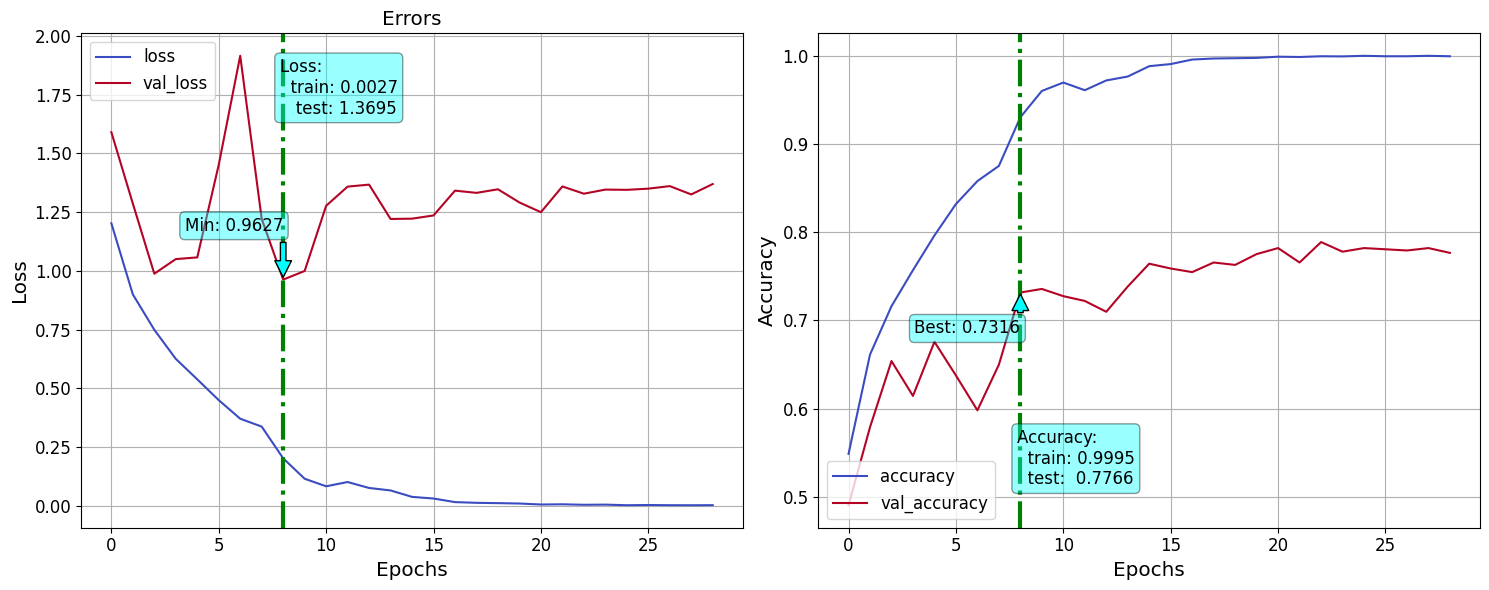

In [25]:
fn_plot_tf_hist(hist_df)

In [26]:
# test dataset

y_true, y_pred = [], []

for feature, label in test_ds:
    pred = model(feature).numpy()
    y_true.extend(label)
    y_pred.extend(pred.argmax(axis=1))
print(f'{classification_report(y_true,y_pred)}')

              precision    recall  f1-score   support

           0       0.72      0.75      0.73       140
           1       0.73      0.84      0.78       175
           2       0.60      0.65      0.62       116
           3       0.76      0.88      0.82       138
           4       0.87      0.53      0.66       165

    accuracy                           0.73       734
   macro avg       0.74      0.73      0.72       734
weighted avg       0.74      0.73      0.73       734



In [27]:
from sklearn.metrics import f1_score, accuracy_score
print(f1_score(y_true, y_pred, average='macro'))
print(accuracy_score(y_true, y_pred))

0.7233918607446641
0.7316076294277929


In [28]:

# data_dir = os.path.join(inpDir, valDir)
# valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
#     data_dir,
#     validation_split=None,
#     #subset='validation',
#     seed= RANDOM_STATE,
#     image_size=(IMG_HEIGHT, IMG_WIDTH),
#     batch_size=BATCH_SIZE)

# valid_ds = valid_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

### Reload best Weights for evaluation

### Evaluate the model

## Validate on the validation set

In [29]:
# data_dir = os.path.join(inpDir, valDir)
# valid_ds = tf.keras.preprocessing.image_dataset_from_directory(
#     data_dir,
#     validation_split=None,
#     #subset='validation',
#     seed= RANDOM_STATE,
#     image_size=(IMG_HEIGHT, IMG_WIDTH),
#     batch_size=BATCH_SIZE)

# valid_ds = valid_ds.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [30]:
# # set figure size
# fig = plt.figure()  # figure size in inches with default params

# # Adjust the subplot layout parameters.
# fig.subplots_adjust(left=0., # as a fraction of the figure width
#                     right=1., # use full width, as a fraction of the figure width
#                     bottom=0., # as a fraction of the figure height
#                     top=1., # as a fraction of the figure height
#                     hspace=0.05, # as a fraction of the average Axes height
#                     wspace=0.05) # width of the padding between subplots
# i = 0
# # take one batch of the dataset
# for images, labels in valid_ds.take(1):
    
#     # iterate through the batch
#     for i in range(BATCH_SIZE):
        
#         # add a subplot
#         ax = fig.add_subplot( BATCH_SIZE//8, 8, (i+1), xticks=[], yticks=[]) # add a subplot to the figure
        
#         # image_size may have converted these images to float
#         ax.imshow(images[i].numpy().astype("uint8")) 
        
#         # display class in the title
#         ax.set_title(class_names[labels[i]])
        
# # fit the subplot(s) in to the figure area
# plt.tight_layout()
    
# # display all open images    
# plt.show()

In [31]:
# loss, acc = new_model.evaluate(valid_ds)

# print('Accuracy score on Validation Data : {:.3f}%'.format( acc*100))

In [32]:
# for images, labels in valid_ds.take(2 ):
    
#     # Predict again to keep y_pred in synch with the images
#     yhat = new_model.predict(images, verbose = 0)
    
#     y_pred = yhat.argmax(axis = 1)
#     fontsize = 12
#     fig = plt.figure()  # figure with default size in inches
    
#     fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05) # adjust subplots

#     for i in range ( BATCH_SIZE ):
        
#         if labels.numpy()[i]!= y_pred[i]:
#             fc = 'purple'
#             ec="red"
#             text_color = 'yellow'
#         else:
#             fc = 'cyan'
#             ec = 'blue'
#             text_color = 'blue'

#         props = dict(boxstyle='round', facecolor=fc, alpha=0.7, ec = ec)
        
#         ax = fig.add_subplot(BATCH_SIZE // 8 , 8, (i+1), xticks=[], yticks=[]) # add a subplot to the figure
        
#         ax.imshow ( images[i].numpy().astype( "uint8" ) )
        
#         ax.text(0.1, 0.95, class_names[y_pred[i]], transform=ax.transAxes, 
#                 fontsize=fontsize, color = text_color,
#             verticalalignment='top', bbox=props)   # add number (class) of the image

        
#         ax.set_title(class_names[labels.numpy()[i]])
#         #ax.set_title('{} \n {}'.format( class_names[labels.numpy()[i]], ))
        
#         ax.axis("off")
        
#     plt.tight_layout()
    
#     plt.show()